In [1]:
# Step 1: Import Libraries

# pandas and numpy are used for data handling and numerical operations,
# Sequential is used to create the CNN model layer-by-layer,
# Conv2D is used to apply convolution operations for feature extraction from images,
# MaxPooling2D is used to reduce image dimensions and extract important features,
# Flatten converts 2D feature maps into a 1D vector,
# Dense is used to create fully connected neural network layers,
# Dropout is used to prevent overfitting by randomly disabling some neurons during training,
# to_categorical converts class labels into one-hot encoded format

import pandas as pd
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical

In [2]:
# Step 2: Load Dataset

train_data = pd.read_csv("fashion-mnist_train.csv")

test_data = pd.read_csv("fashion-mnist_test.csv")

print(train_data.head())

   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [3]:
# Step 3: Separate Features and Labels

# X_train contains input image pixel values used for training,
# data.drop("label", axis=1) removes the label column
# and keeps only image feature data

X_train = train_data.drop("label", axis=1)

# y_train contains the target/output labels (image categories)

y_train = train_data["label"]

# X_test contains input image pixel values used for testing

X_test = test_data.drop("label", axis=1)

# y_test contains actual labels for testing data

y_test = test_data["label"]

In [4]:
# Step 4: Normalize Pixel Values

# Image pixel values usually range from 0 to 255,
# dividing by 255.0 converts values into the range 0 to 1,
# normalization helps the CNN model train faster and improves accuracy

X_train = X_train / 255.0

X_test = X_test / 255.0

In [5]:
# Step 5: Reshape Images

# CNN models require image data in 4D format:
# (number_of_images, height, width, channels)

# reshape(-1, 28, 28, 1):
# -1 automatically calculates the number of images,
# 28 = image height,
# 28 = image width,
# 1 = grayscale color channel

X_train = X_train.values.reshape(-1, 28, 28, 1)

X_test = X_test.values.reshape(-1, 28, 28, 1)

# .shape displays the dimensions of training and testing datasets

print("Training Shape:", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape: (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


In [6]:
# Step 6: Convert Labels into Categorical Format

# to_categorical() converts class labels into one-hot encoded format,
# this is required for multi-class classification problems

# Example:
# Label 3 becomes:
# [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

# Each class is represented using binary values,
# where only the correct class index is 1

y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

In [8]:
# Step 7: Build CNN Model

# Sequential() creates the CNN model layer-by-layer

model = Sequential()

# First Convolution Layer:
# Conv2D applies filters/kernels to extract image features,
# 32 means 32 filters are used,
# (3,3) is the filter/kernel size,
# ReLU activation introduces non-linearity,
# input_shape=(28,28,1) means:
# 28 = image height,
# 28 = image width,
# 1 = grayscale channel

model.add(
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    )
)

# MaxPooling2D reduces image dimensions,
# (2,2) pooling keeps important features
# and reduces computation

model.add(
    MaxPooling2D((2, 2))
)

# Second Convolution Layer:
# 64 filters are used to learn more complex features

model.add(
    Conv2D(
        64,
        (3, 3),
        activation='relu'
    )
)

# Second Pooling Layer

model.add(
    MaxPooling2D((2, 2))
)

# Flatten converts 2D feature maps into a 1D vector
# before sending data to fully connected layers

model.add(Flatten())

# Fully Connected Dense Layer:
# 128 neurons are used for learning patterns

model.add(
    Dense(
        128,
        activation='relu'
    )
)

# Dropout randomly disables 30% neurons during training
# to reduce overfitting

model.add(
    Dropout(0.3)
)

# Output Layer:
# Dense(10) means 10 output classes,
# softmax activation converts outputs into probabilities,
# the class with highest probability becomes prediction

model.add(
    Dense(
        10,
        activation='softmax'
    )
)

C:\Users\tusha\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Step 8: Compile Model

# model.compile() configures the CNN model for training,
# optimizer updates model weights,
# loss function measures prediction error,
# metrics evaluate model performance

model.compile(
    
    # Adam optimizer is used for faster and efficient training
    
    optimizer='adam',
    
    # categorical_crossentropy is used for multi-class classification,
    # Formula:
    # Loss = -Σ(y * log(y_pred))
    # where:
    # y = actual class label
    # y_pred = predicted probability
    
    loss='categorical_crossentropy',
    
    # accuracy measures how many predictions are correct
    
    metrics=['accuracy']
)

In [10]:
# Step 9: Train Model

# model.fit() is used to train the CNN model using training data,
# the model learns image patterns by updating weights repeatedly

history = model.fit(
    
    # Input training images
    
    X_train,
    
    # Target class labels
    
    y_train,
    
    # epochs=5 means the complete training dataset
    # passes through the neural network 5 times
    
    epochs=5,
    
    # batch_size=64 means 64 images are processed together
    # before updating model weights
    
    batch_size=64,
    
    # validation_split=0.1 means 10% of training data
    # is used for validation during training
    
    validation_split=0.1,
    
    # verbose=1 displays training progress for each epoch
    
    verbose=1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.7952 - loss: 0.5607 - val_accuracy: 0.8657 - val_loss: 0.3776
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.8662 - loss: 0.3704 - val_accuracy: 0.8827 - val_loss: 0.3235
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.8828 - loss: 0.3226 - val_accuracy: 0.8950 - val_loss: 0.2935
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.8933 - loss: 0.2918 - val_accuracy: 0.8937 - val_loss: 0.2912
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9014 - loss: 0.2648 - val_accuracy: 0.8997 - val_loss: 0.2688


In [10]:
# Step 10: Evaluate Model

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9032 - loss: 0.2593

Test Accuracy: 0.9031999707221985


In [11]:
# Train the CNN Model

# model.fit() trains the neural network using training data,
# the model learns patterns by adjusting weights during training

history = model.fit(
    
    # Input training images
    
    X_train,
    
    # Actual training labels
    
    y_train,
    
    # epochs=10 means the complete training dataset
    # passes through the model 10 times
    
    epochs=10,
    
    # validation_data=(X_test, y_test) uses testing data
    # to evaluate model performance after each epoch,
    # helps monitor accuracy and overfitting during training
    
    validation_data=(X_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9004 - loss: 0.2709 - val_accuracy: 0.9092 - val_loss: 0.2497
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9118 - loss: 0.2396 - val_accuracy: 0.9091 - val_loss: 0.2520
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9193 - loss: 0.2187 - val_accuracy: 0.9154 - val_loss: 0.2264
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9247 - loss: 0.2043 - val_accuracy: 0.9138 - val_loss: 0.2335
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9297 - loss: 0.1864 - val_accuracy: 0.9172 - val_loss: 0.2367
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - accuracy: 0.9354 - loss: 0.1716 - val_accuracy: 0.9202 - val_loss: 0.2336
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9387 - loss: 0.1616 - val_accuracy: 0.9219 - val_loss: 0.2222
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9423 -

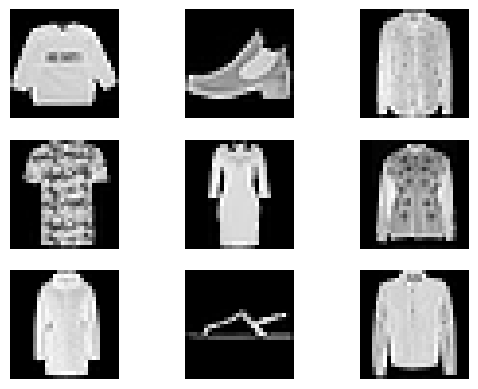

In [12]:
# Import matplotlib library for data visualization and plotting images

import matplotlib.pyplot as plt

# Loop runs 9 times to display first 9 training images

for i in range(9):
    
    # subplot(3,3,i+1) creates a 3x3 grid layout,
    # i+1 specifies the current image position
    
    plt.subplot(3,3,i+1)
    
    # imshow() displays the image,
    # X_train[i] selects the ith image,
    # cmap='gray' displays image in grayscale format
    
    plt.imshow(X_train[i], cmap='gray')
    
    # axis('off') hides x-axis and y-axis values
    
    plt.axis('off')

# show() displays all plotted images

plt.show()

In [13]:
# Step 11: Predict Classes

# model.predict() generates probability predictions
# for each class using the testing dataset

predictions = model.predict(X_test)

# np.argmax(..., axis=1) selects the index of the highest probability
# from each prediction row,
# this gives the predicted class label

predicted_classes = np.argmax(predictions, axis=1)

# y_test is one-hot encoded,
# np.argmax(..., axis=1) converts one-hot vectors
# back into original class labels

actual_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [14]:
# Step 12: Display Predictions

# Dictionary containing class labels for Fashion MNIST dataset,
# each numeric class is mapped to its clothing category name

fashion_labels = {

    0: "T-shirt",

    1: "Trouser",

    2: "Pullover",

    3: "Dress",

    4: "Coat",

    5: "Sandal",

    6: "Shirt",

    7: "Sneaker",

    8: "Bag",

    9: "Ankle Boot"
}

# pd.DataFrame() creates a comparison table
# between actual and predicted class labels

results = pd.DataFrame({

    # actual_classes[:10] selects first 10 actual labels,
    # list comprehension converts numeric labels into category names
    
    "Actual": [fashion_labels[i] for i in actual_classes[:10]],

    # predicted_classes[:10] selects first 10 predicted labels,
    # numeric labels are converted into category names
    
    "Predicted": [fashion_labels[i] for i in predicted_classes[:10]]
})

print("\nActual vs Predicted:\n")

# Display the comparison table

print(results)


Actual vs Predicted:

     Actual Predicted
0   T-shirt   T-shirt
1   Trouser   Trouser
2  Pullover  Pullover
3  Pullover  Pullover
4     Dress     Dress
5  Pullover     Shirt
6       Bag       Bag
7     Shirt     Shirt
8    Sandal    Sandal
9   T-shirt   T-shirt
